# Подготовка данных

Что здесь происходит:

1. Время публикации переводится из UTC в московское
2. Отбрасываются посты до 2017 года: тогда VK ещё не считал просмотры, и у 46% постов в выгрузке стоит 0
3. Считаются признаки, известные до публикации (время, текст, темп постинга, текущий уровень охватов сообщества)

Выбросы по просмотрам и лайкам **не удаляются**: вирусные посты и есть самое интересное, и модель, обученная без них, не научится их замечать

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from features import PREPARED_FILE, VIEWS_START, add_features, load_raw

plt.rcParams["figure.dpi"] = 100

In [2]:
raw = load_raw()
print(f"Всего постов: {len(raw)}, период {raw['Дата публикации'].min():%Y-%m-%d} - {raw['Дата публикации'].max():%Y-%m-%d}")

by_year = raw.groupby(raw["Дата публикации"].dt.year).agg(
    постов=("Post ID", "size"),
    доля_нулевых_просмотров=("Просмотры", lambda s: round((s == 0).mean(), 2)),
    медиана_просмотров=("Просмотры", "median"),
    медиана_лайков=("Лайки", "median"),
)
by_year

Всего постов: 9000, период 2012-12-01 - 2025-08-02


,постов,доля_нулевых_просмотров,медиана_просмотров,медиана_лайков
Дата публикации,,,,
2012,80,1.0,0.0,8.5
2013,936,1.0,0.0,7.0
2014,946,1.0,0.0,19.0
2015,1321,1.0,0.0,20.0
2016,833,1.0,0.0,29.0
2017,1138,0.0,1422.0,50.0
2018,606,0.0,1728.5,57.0
2019,542,0.0,1551.0,57.5
2020,457,0.0,1602.0,52.0


До 2017 года просмотров нет вообще, дальше медианный охват растёт почти вдвое. Это важно для модели: уровень сообщества меняется со временем, и случайное разбиение на train/test здесь нечестное, будущие посты окажутся в обучении

In [3]:
df = raw[raw["Дата публикации"] >= VIEWS_START].reset_index(drop=True)
df = add_features(df)
print(f"Постов с 2017 года: {len(df)}")
df[["Дата публикации", "Просмотры", "Лайки", "hour", "len", "emoji", "category", "level_views"]].tail()

Постов с 2017 года: 4884


,Дата публикации,Просмотры,Лайки,hour,len,emoji,category,level_views
4879,2025-07-22 21:19:14,2883,112,21,59,2,Матч / Результаты,9.604873
4880,2025-07-24 23:40:54,45793,194,23,17,2,Другое,9.151556
4881,2025-07-26 23:23:06,3304,207,23,23,0,Другое,9.604873
4882,2025-07-30 16:15:16,6022,392,16,66,1,Матч / Результаты,9.151556
4883,2025-08-02 21:10:06,579,27,21,3,3,Другое,8.957750


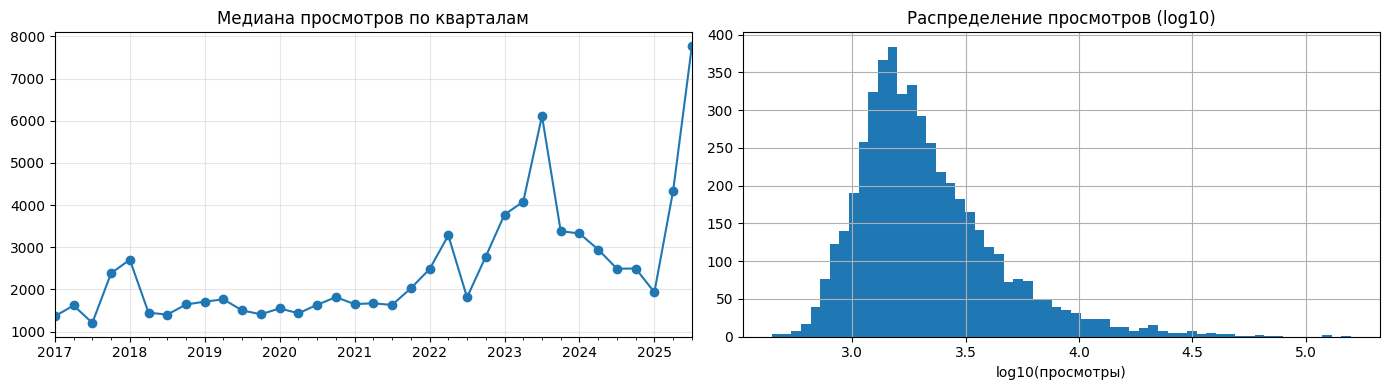

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = df.set_index("Дата публикации")[["Просмотры", "Лайки"]].resample("QE").median()
monthly["Просмотры"].plot(ax=axes[0], marker="o")
axes[0].set_title("Медиана просмотров по кварталам")
axes[0].set_xlabel("")
axes[0].grid(alpha=0.3)

np.log10(df["Просмотры"].clip(lower=1)).hist(bins=60, ax=axes[1])
axes[1].set_title("Распределение просмотров (log10)")
axes[1].set_xlabel("log10(просмотры)")
plt.tight_layout()
plt.savefig("../images/views_over_time.png", bbox_inches="tight")
plt.show()

Распределение сильно скошено: пара вирусных постов набирает в десятки раз больше медианы. Поэтому модель дальше учится на `log1p(просмотры)`, а качество смотрим и в логарифме, и в исходных единицах

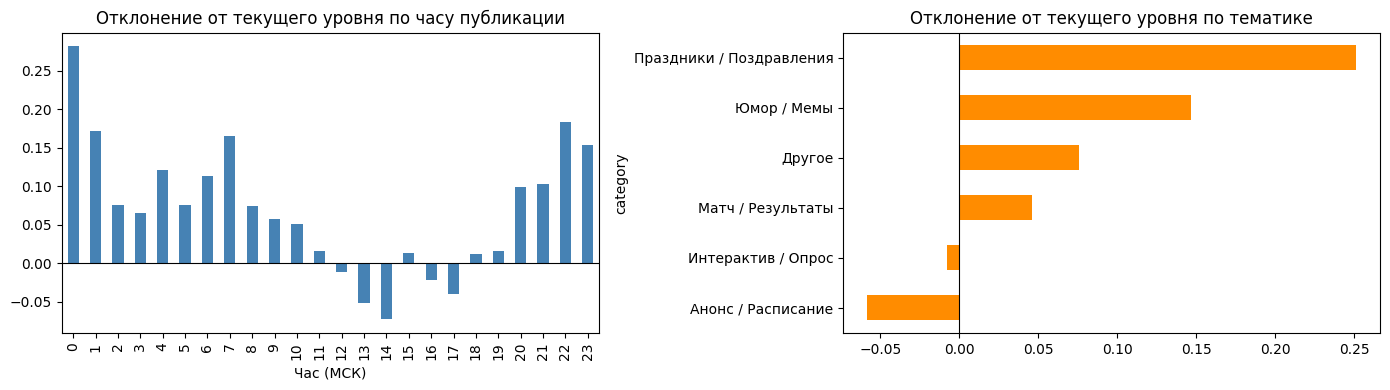

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rel = np.log1p(df["Просмотры"]) - df["level_views"]

rel.groupby(df["hour"]).mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Отклонение от текущего уровня по часу публикации")
axes[0].set_xlabel("Час (МСК)")
axes[0].axhline(0, color="k", lw=0.8)

rel.groupby(df["category"]).mean().sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Отклонение от текущего уровня по тематике")
axes[1].axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.savefig("../images/hour_and_category.png", bbox_inches="tight")
plt.show()

По оси Y здесь не сырые просмотры, а разница между log-просмотрами поста и медианой по 20 предыдущим. Так рост сообщества не смешивается с эффектом часа или тематики

In [6]:
df.to_csv(PREPARED_FILE, index=False)
print("Сохранено:", PREPARED_FILE.name)

Сохранено: vk_posts_prepared.csv
